# Task 8 — Validation-based classification experiments

**Abdlrhman Hisham Ismail · AI2617 · IEEE SSCS AUSC AI Sub-Team**

Classify the [UCI Mushroom dataset](https://archive.ics.uci.edu/dataset/73/mushroom) as edible (`0`) or poisonous (`1`). Compare ordinal and one-hot features using identical data partitions, scalers, models, seeds, and full assignment grids.

| Model | Search grid |
| :--- | :--- |
| KNN | K = 2 … 150 |
| SGD logistic regression | learning rate = 0.001 … 1.000, step 0.001 |
| LBFGS logistic regression | max_iter = 1,000 … 100,000, step 1,000 |

**Protocol:** split 60% train / 20% validation / 20% test; fit preprocessing only on train; choose settings on validation, preferring the smallest tie; freeze every setting for both encodings before any test evaluation; refit on train + validation and report test F1 once per selected model. Positive class is poisonous.

Saved results are displayed by default. Set `RECOMPUTE = True` below to regenerate all 2,498 candidate evaluations plus six final fits. The [legacy outputs](legacy/README.md) retain the original educational train/test curves and their limitations. This revised test partition was already inspected in the older submission, so it is not a new external blind benchmark.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
from evaluation import load_split, run_experiment, choose_setting, GRIDS

# The kernel working directory must be this Task8 folder.
ROOT = Path.cwd()
assert (ROOT / "mushrooms.csv").is_file(), "Start the kernel in Machine-Learning/Tasks/Task8"
RECOMPUTE = False
split = load_split(ROOT / "mushrooms.csv")
print("Train / validation / test:", len(split.y_train), len(split.y_validation), len(split.y_test))
display(split.X_train.head())

Train / validation / test: 4874 1625 1625


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
1701,f,s,w,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,s,g
2751,x,f,g,t,n,f,c,b,p,t,...,s,p,p,p,w,o,p,n,y,d
4074,f,y,n,t,n,f,c,b,p,t,...,s,g,g,p,w,o,p,n,v,d
6980,k,s,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l
7105,x,s,e,f,y,f,c,n,b,t,...,k,p,p,p,w,o,e,w,v,p


## Reproduce or inspect the saved run

`evaluation.py` contains the computation; the notebook is its readable report. Only training/validation data enter the tuning API. Both encodings use `StandardScaler`; ordinal encoding is a baseline and assigns arbitrary numeric geometry to categories. One-hot avoids that ordering, but standardized indicators weight rare categories more strongly. It is the predefined primary representation, not a choice based on final test scores.

In [2]:
names = {"knn": "knn_f1_by_k", "sgd": "logreg_f1_by_lr", "logreg": "logreg_f1_by_iter"}
if RECOMPUTE:
    final, tables, protocol = run_experiment(ROOT)
else:
    protocol = json.loads((ROOT / "results/evaluation_protocol.json").read_text())
    final = pd.read_csv(ROOT / "results/encoding_comparison.csv")
    tables = {encoding: {kind: pd.read_csv(ROOT / "results" / f"{encoding}_{name}.csv")
                       for kind, name in names.items()} for encoding in ("ordinal", "onehot")}

# Validate saved grid sizes and choices rather than selecting from test metrics.
for encoding, sweeps in tables.items():
    for kind, table in sweeps.items():
        parameter, values = GRIDS[kind]
        assert len(table) == len(values)
        assert "test_F1" not in table.columns
        assert choose_setting(table, parameter) == protocol["selections"][encoding][kind]["value"]
print(json.dumps(protocol, indent=2))

{
  "python": "3.13.13",
  "numpy": "2.5.2",
  "pandas": "3.0.5",
  "scikit_learn": "1.9.0",
  "seed": 42,
  "train_rows": 4874,
  "validation_rows": 1625,
  "test_rows": 1625,
  "encoded_features": {
    "ordinal": 22,
    "onehot": 117
  },
  "selections": {
    "ordinal": {
      "knn": {
        "parameter": "K",
        "value": 2
      },
      "sgd": {
        "parameter": "learning_rate",
        "value": 0.028
      },
      "logreg": {
        "parameter": "max_iter",
        "value": 1000
      }
    },
    "onehot": {
      "knn": {
        "parameter": "K",
        "value": 2
      },
      "sgd": {
        "parameter": "learning_rate",
        "value": 0.001
      },
      "logreg": {
        "parameter": "max_iter",
        "value": 1000
      }
    }
  },
  "primary_encoding": "onehot",
  "selection_metric": "validation_F1",
  "tie_break": "smallest parameter within 1e-12 of best validation F1",
  "test_policy": "all settings frozen before test evaluation; no test sweep

## KNN: train/validation curves

K is chosen on validation only. Both representations selected K=2 on this run. Perfect validation performance on this dataset does not establish performance on other populations.

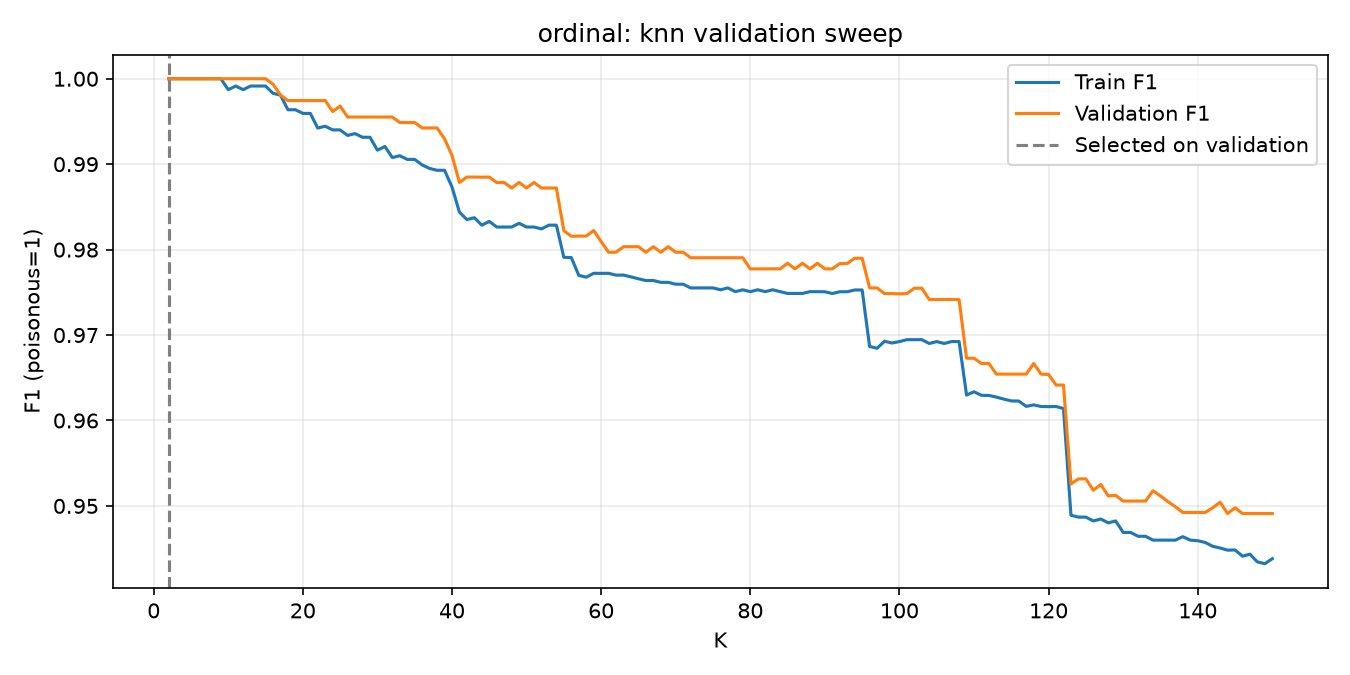

,K,train_F1,validation_F1,convergence_warnings
0,2,1.0,1.0,0
1,3,1.0,1.0,0
2,4,1.0,1.0,0
3,5,1.0,1.0,0
4,6,1.0,1.0,0


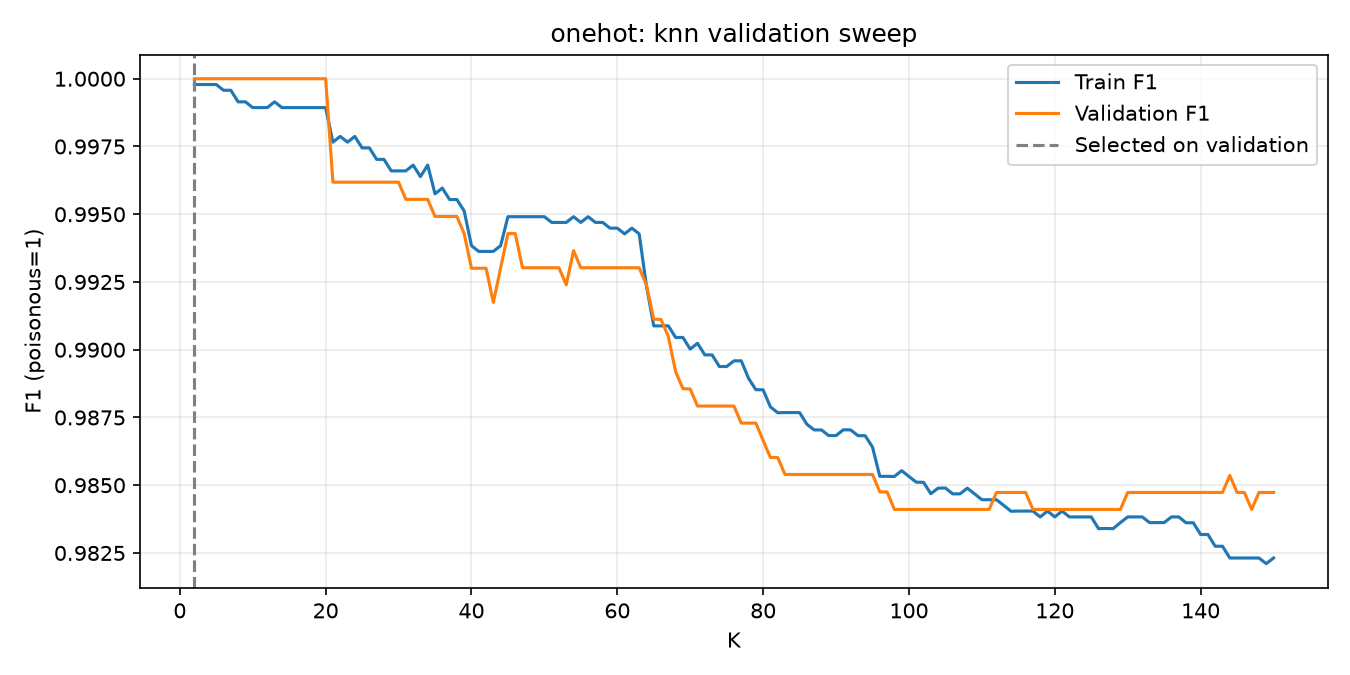

,K,train_F1,validation_F1,convergence_warnings
0,2,0.999787,1.0,0
1,3,0.999787,1.0,0
2,4,0.999787,1.0,0
3,5,0.999787,1.0,0
4,6,0.999574,1.0,0


In [3]:
for encoding in ("ordinal", "onehot"):
    display(Image(filename=str(ROOT / "plots" / f"{encoding}_knn_validation.png")))
    display(tables[encoding]["knn"].head())

## Learning rate: SGD logistic regression

The model uses `loss="log_loss"`, constant steps, no penalty, `max_iter=1000`, and `random_state=42`. Candidate convergence warnings are counted in the CSV instead of silently discarded. Validation selected eta=0.028 for ordinal features and eta=0.001 for one-hot features on this run.

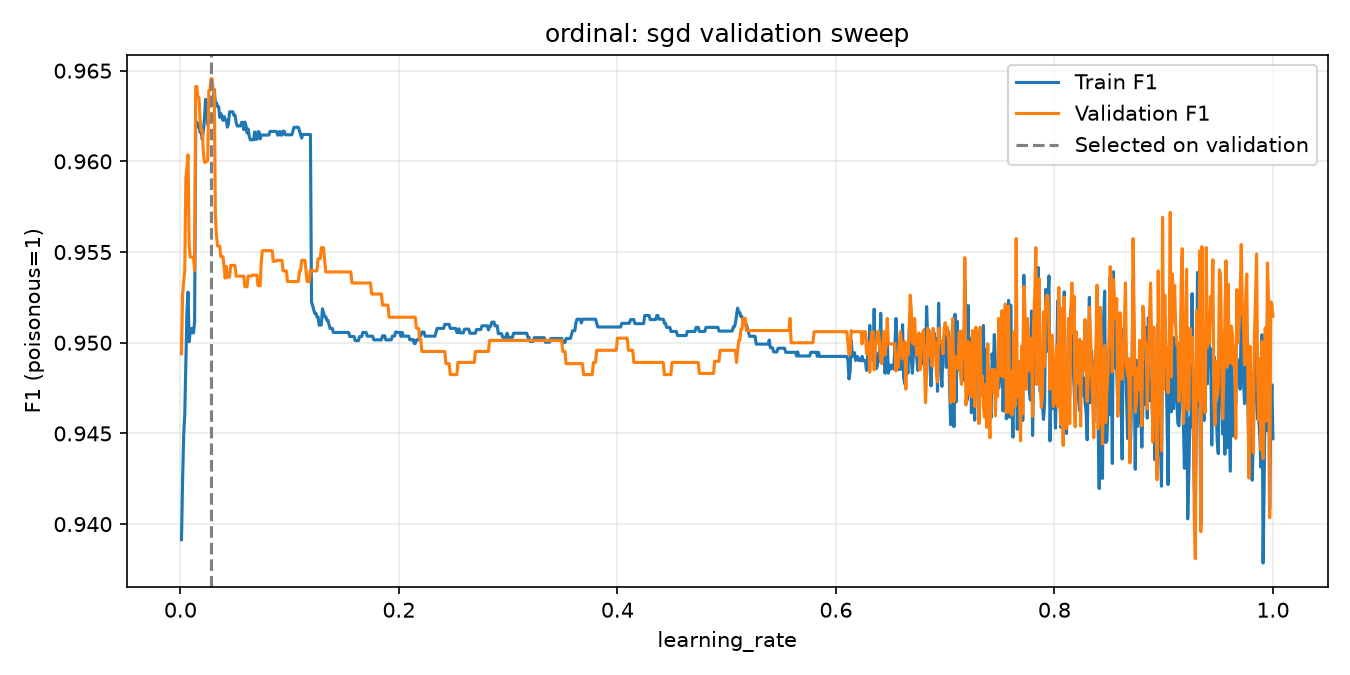

ordinal sweep convergence warnings: 0


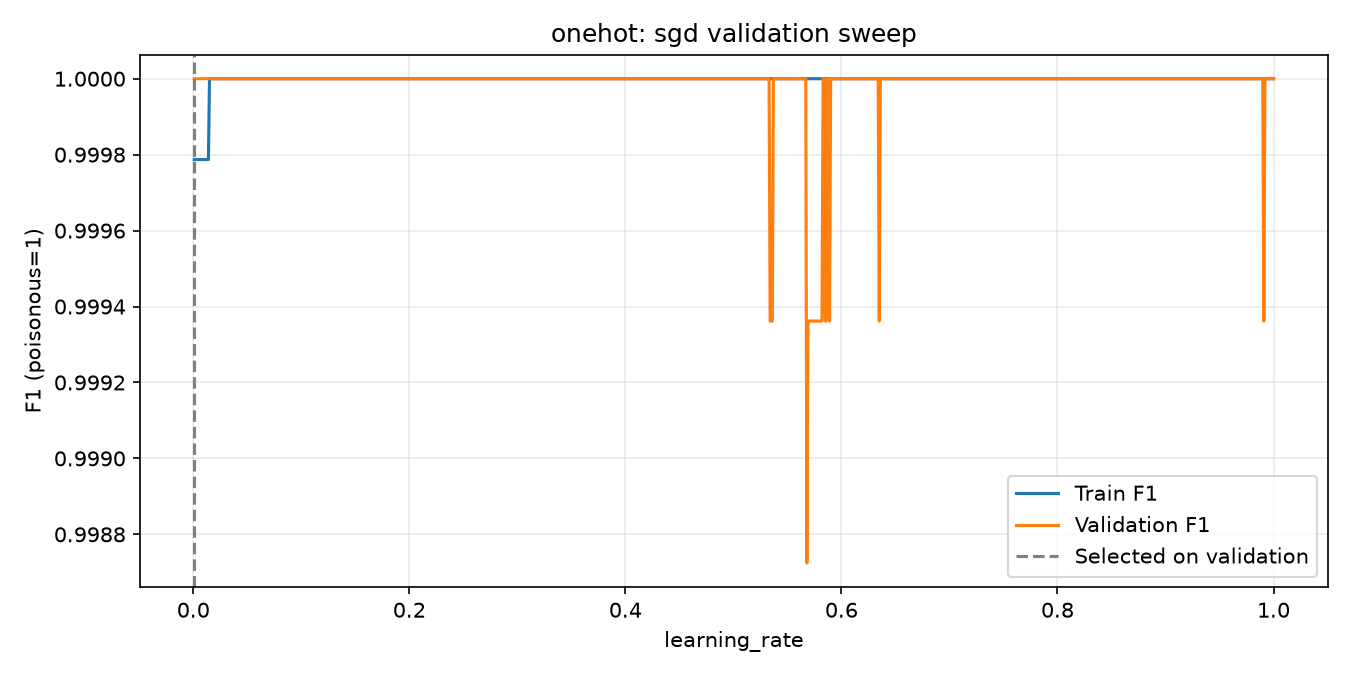

onehot sweep convergence warnings: 0


In [4]:
for encoding in ("ordinal", "onehot"):
    display(Image(filename=str(ROOT / "plots" / f"{encoding}_sgd_validation.png")))
    print(encoding, "sweep convergence warnings:", int(tables[encoding]["sgd"]["convergence_warnings"].sum()))

## Iteration limit: LBFGS logistic regression

`max_iter` is an upper bound, not a promise that the solver takes that many iterations. With fixed C=1, validation ties selected the smallest budget (1,000).

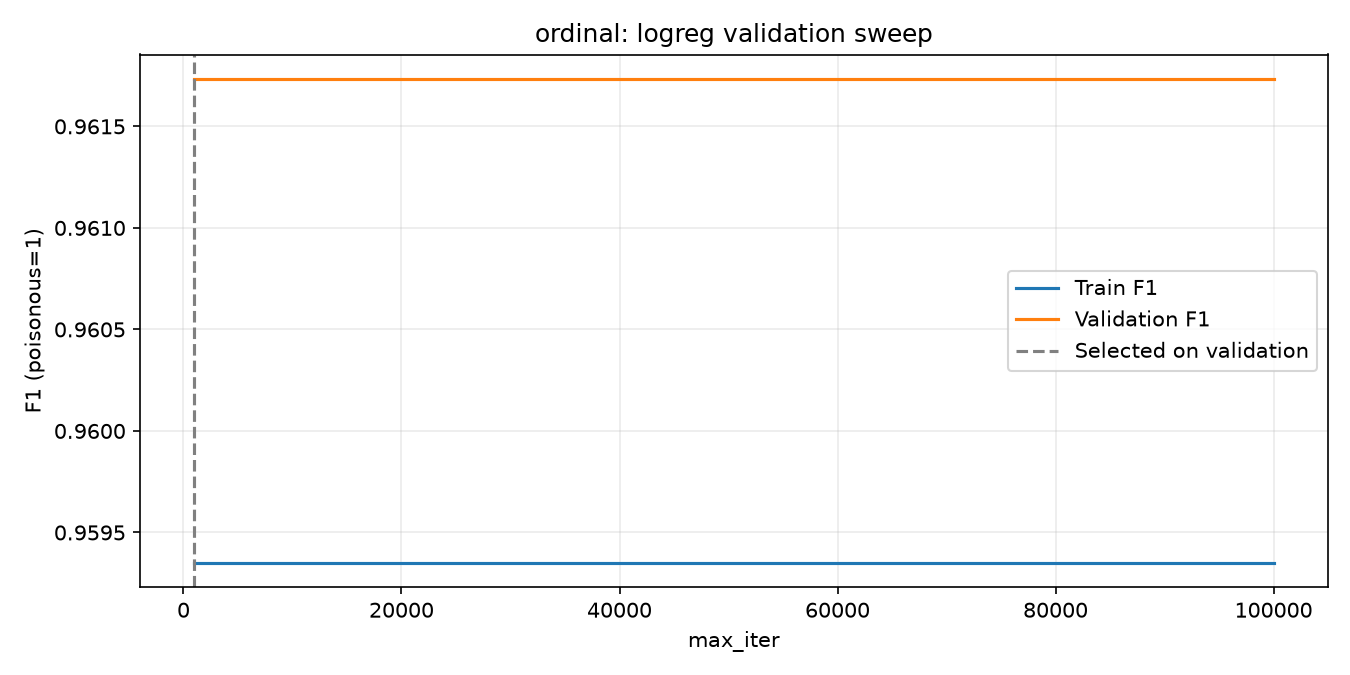

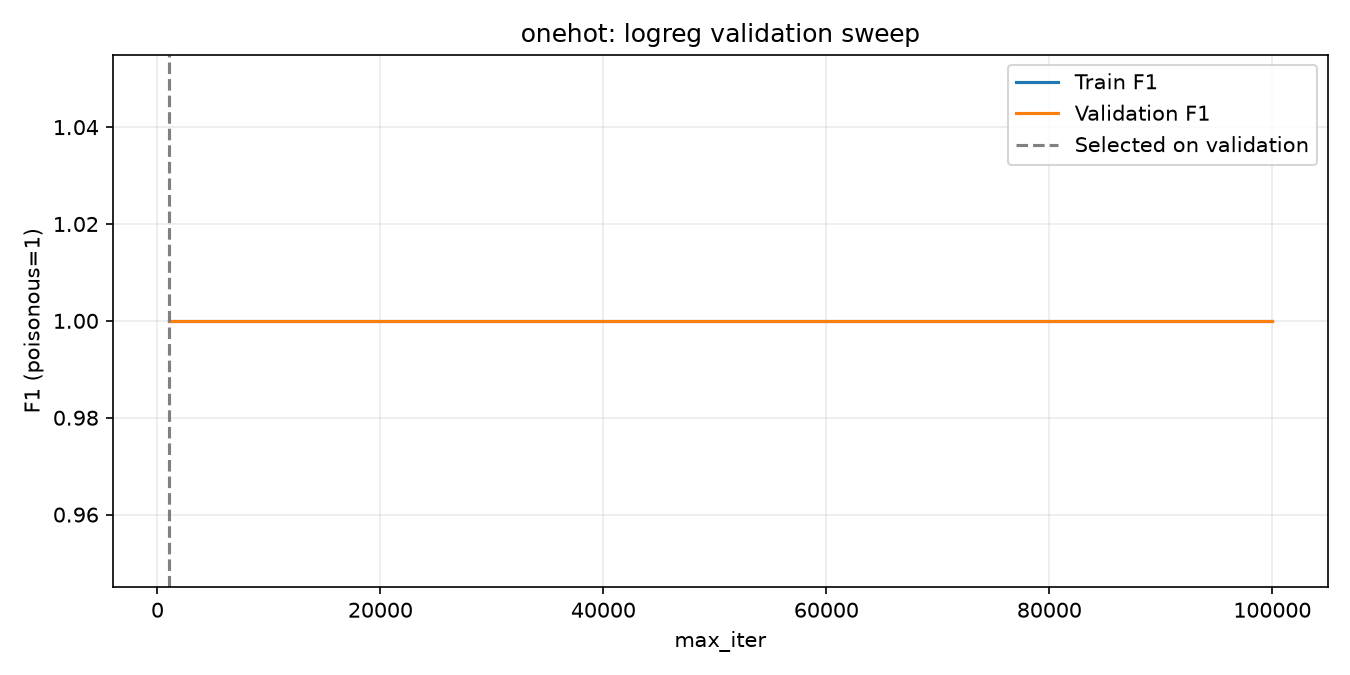

In [5]:
for encoding in ("ordinal", "onehot"):
    display(Image(filename=str(ROOT / "plots" / f"{encoding}_logreg_validation.png")))

## Final test comparison after freezing settings

Validation F1 is from the 60% training fit; `refit_train_F1` and test F1 are from the final model fitted on the 80% development partition. One-hot improved the two linear classifiers in this run, while KNN test F1 decreased slightly. Do not retune using this table. This is one deterministic split; no confidence interval or external validation is claimed.

In [6]:
display(final)
assert len(final) == 6
assert final["refit_convergence_warnings"].sum() == 0
print("Primary encoding:", protocol["primary_encoding"])
print("Selection metric:", protocol["selection_metric"])

,encoding,model,parameter,value,refit_train_F1,test_F1,refit_convergence_warnings,validation_F1
0,ordinal,knn,K,2.000,1.000000,1.000000,0,1.000000
1,ordinal,sgd,learning_rate,0.028,0.958608,0.960154,0,0.964557
2,ordinal,logreg,max_iter,1000.000,0.959756,0.961022,0,0.961735
3,onehot,knn,K,2.000,0.999840,0.998721,0,1.000000
4,onehot,sgd,learning_rate,0.001,0.999840,0.998721,0,1.000000
5,onehot,logreg,max_iter,1000.000,1.000000,1.000000,0,1.000000


Primary encoding: onehot
Selection metric: validation_F1


## Sources and checks

Mushroom [Dataset] (1981), UCI Machine Learning Repository, DOI [10.24432/C5959T](https://doi.org/10.24432/C5959T). UCI publishes the dataset under CC BY 4.0. `mushrooms.csv` gives named columns and converts the raw 2,480 missing stalk-root markers to empty CSV fields; missing categories and target encoding are described above. See [repository attribution](../../../THIRD_PARTY_NOTICES.md).

Run `python -m unittest discover -s tests -v` for split isolation, validation-only selection, unknown-category handling, and cached/full-pipeline equivalence. Package versions used for the saved run are in `requirements-evaluation.txt` and the protocol JSON.